<a href="https://colab.research.google.com/github/AleximperV/ThucHanhDeepLearning/blob/main/Tuan_2/GiaNhaDat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- BƯỚC 1: TẢI & LÀM SẠCH DỮ LIỆU ---
Không có dòng dữ liệu trùng lặp.
Không có giá trị khuyết thiếu.
Kích thước tập dữ liệu sau khi làm sạch: (500, 9)

--- BƯỚC 2: TRỰC QUAN HÓA DỮ LIỆU KHÁM PHÁ ---


/tmp/ipykernel_19850/1100508758.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Bedrooms', y='Selling_Price', ax=axes[4], palette="light:b")
/tmp/ipykernel_19850/1100508758.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Baths_full', y='Selling_Price', ax=axes[5], palette="light:b")


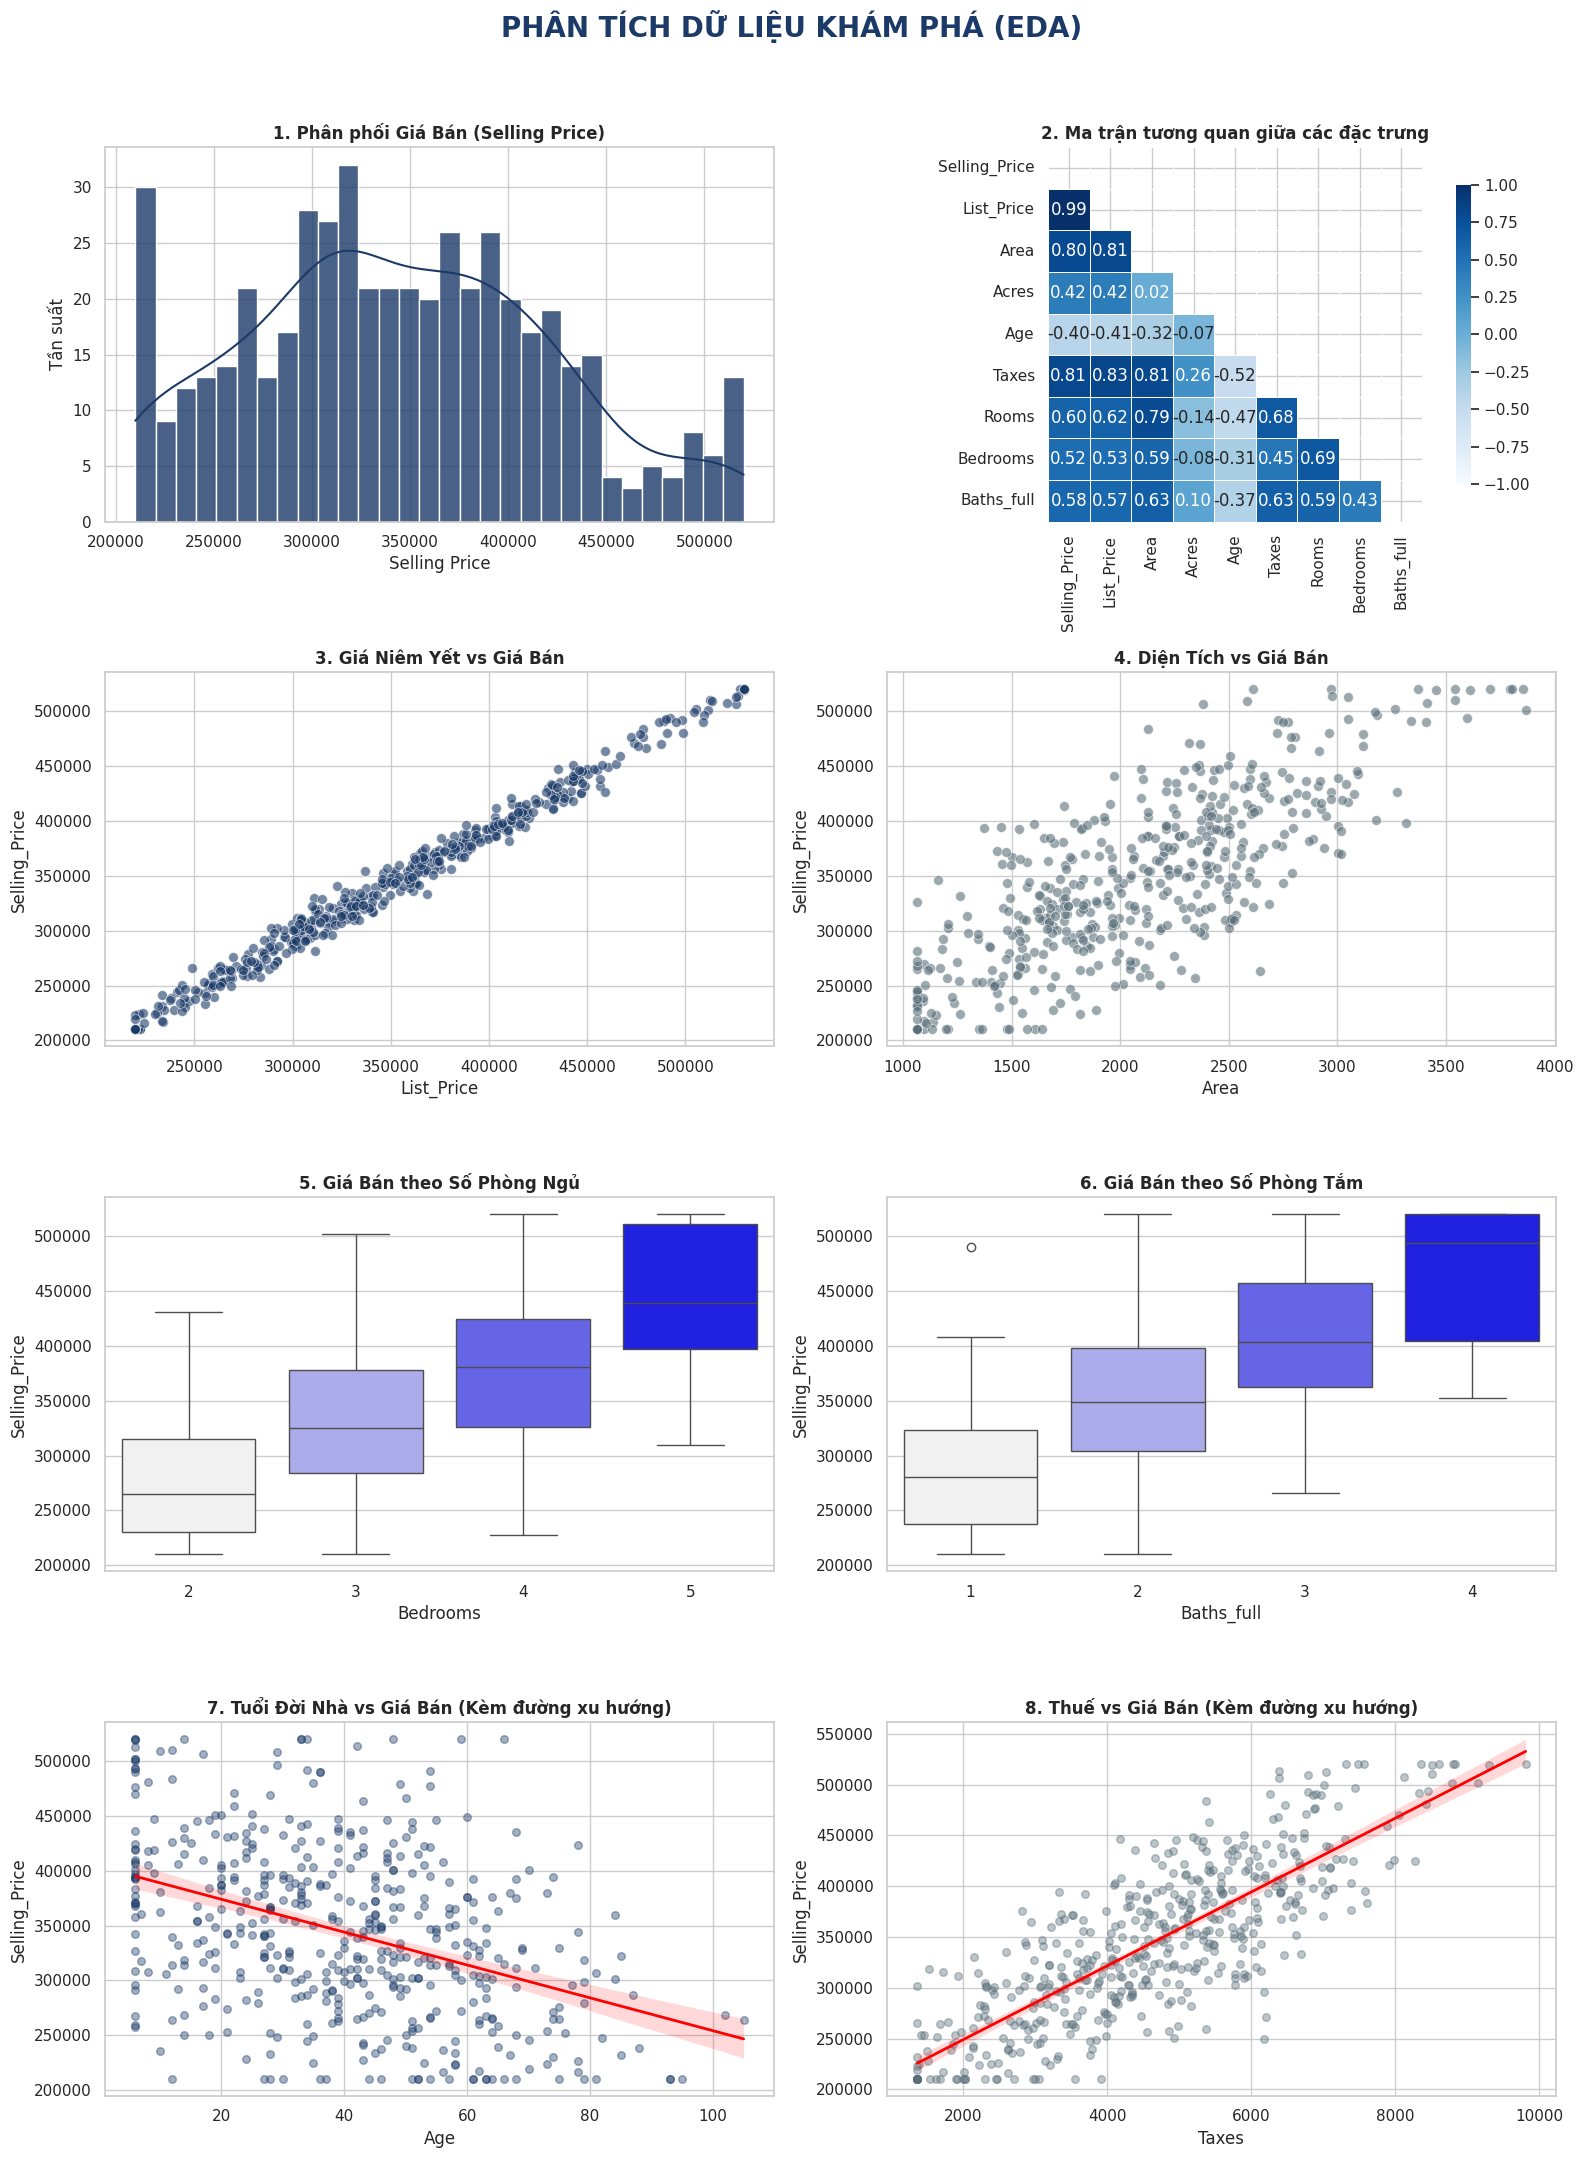


--- BƯỚC 3: XÂY DỰNG PIPELINE CHUẨN MỰC ---
Kích thước tập Train (60%): 300 dòng
Kích thước tập Val (20%): 100 dòng
Kích thước tập Test (20%): 100 dòng

Huấn luyện thành công!

Độ chính xác (R^2 Score) trên tập Validation: 0.9896
Độ chính xác (R^2 Score) trên tập Test ẩn: 0.9891


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression

# ==========================================
# 1. TẢI VÀ KIỂM TRA DỮ LIỆU
# ==========================================
print("--- BƯỚC 1: TẢI & LÀM SẠCH DỮ LIỆU ---")
# Lưu ý: Cập nhật đường dẫn file nếu cần thiết
df = pd.read_csv('/content/drive/MyDrive/generated_500_homes.csv')

# Kiểm tra dữ liệu trùng lặp
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Phát hiện {duplicates} dòng trùng lặp. Đang tiến hành xóa...")
    df = df.drop_duplicates()
else:
    print("Không có dòng dữ liệu trùng lặp.")

# Kiểm tra giá trị khuyết thiếu (Missing values)
missing_values = df.isnull().sum().sum()
if missing_values > 0:
    print(f"Phát hiện {missing_values} giá trị khuyết thiếu. Đang tiến hành xử lý (Drop)...")
    df = df.dropna()
else:
    print("Không có giá trị khuyết thiếu.")

print(f"Kích thước tập dữ liệu sau khi làm sạch: {df.shape}\n")


# ==========================================
# 2. TRỰC QUAN HÓA DỮ LIỆU (EDA) - 8 SƠ ĐỒ
# ==========================================
print("--- BƯỚC 2: TRỰC QUAN HÓA DỮ LIỆU KHÁM PHÁ ---")
# Cấu hình phong cách biểu đồ: Tối giản, sáng, chuyên nghiệp
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.0)
navy_accent = "#1B3A68"
gray_accent = "#596E79"

# Tạo lưới biểu đồ 4 hàng x 2 cột
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()
fig.suptitle('PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA)', fontsize=20, fontweight='bold', color=navy_accent, y=0.98)

# Sơ đồ 1: Phân phối của biến mục tiêu (Selling_Price)
sns.histplot(df['Selling_Price'], kde=True, ax=axes[0], color=navy_accent, bins=30, edgecolor='white', alpha=0.8)
axes[0].set_title('1. Phân phối Giá Bán (Selling Price)', fontweight='bold')
axes[0].set_xlabel('Selling Price')
axes[0].set_ylabel('Tần suất')

# Sơ đồ 2: Ma trận tương quan (Correlation Heatmap)
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
            vmax=1.0, vmin=-1.0, square=True, linewidths=.5, cbar_kws={"shrink": .8})
axes[1].set_title('2. Ma trận tương quan giữa các đặc trưng', fontweight='bold')

# Sơ đồ 3: Quan hệ giữa List_Price và Selling_Price
sns.scatterplot(data=df, x='List_Price', y='Selling_Price', ax=axes[2], color=navy_accent, alpha=0.6, s=50)
axes[2].set_title('3. Giá Niêm Yết vs Giá Bán', fontweight='bold')

# Sơ đồ 4: Quan hệ giữa Area (Diện tích) và Selling_Price
sns.scatterplot(data=df, x='Area', y='Selling_Price', ax=axes[3], color=gray_accent, alpha=0.6, s=50)
axes[3].set_title('4. Diện Tích vs Giá Bán', fontweight='bold')

# Sơ đồ 5: Phân phối Giá bán theo số Phòng ngủ (Bedrooms)
sns.boxplot(data=df, x='Bedrooms', y='Selling_Price', ax=axes[4], palette="light:b")
axes[4].set_title('5. Giá Bán theo Số Phòng Ngủ', fontweight='bold')

# Sơ đồ 6: Phân phối Giá bán theo số Phòng tắm (Baths_full)
sns.boxplot(data=df, x='Baths_full', y='Selling_Price', ax=axes[5], palette="light:b")
axes[5].set_title('6. Giá Bán theo Số Phòng Tắm', fontweight='bold')

# Sơ đồ 7: Quan hệ giữa Tuổi đời nhà (Age) và Selling_Price
sns.regplot(data=df, x='Age', y='Selling_Price', ax=axes[6], color=navy_accent,
            scatter_kws={'alpha':0.4, 's':30}, line_kws={'color':'red', 'lw':2})
axes[6].set_title('7. Tuổi Đời Nhà vs Giá Bán (Kèm đường xu hướng)', fontweight='bold')

# Sơ đồ 8: Quan hệ giữa Thuế (Taxes) và Selling_Price
sns.regplot(data=df, x='Taxes', y='Selling_Price', ax=axes[7], color=gray_accent,
            scatter_kws={'alpha':0.4, 's':30}, line_kws={'color':'red', 'lw':2})
axes[7].set_title('8. Thuế vs Giá Bán (Kèm đường xu hướng)', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# ==========================================
# 3. PIPELINE TIỀN XỬ LÝ & HUẤN LUYỆN (CHIA 3 TẬP)
# ==========================================
print("\n--- BƯỚC 3: XÂY DỰNG PIPELINE CHUẨN MỰC ---")

# Tách biến mục tiêu và đặc trưng
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# ---------------------------------------------------------
# QUY TRÌNH CHIA 3 TẬP: TRAIN (60%) - VAL (20%) - TEST (20%)
# ---------------------------------------------------------
# Lần 1: Tách 20% cho tập Test, giữ lại 80% (Train + Val)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lần 2: Tách 80% còn lại thành Train và Val.
# Để Val chiếm 20% tổng dữ liệu ban đầu, ta dùng test_size = 0.25 (vì 0.25 * 80% = 20%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Kích thước tập Train (60%): {X_train.shape[0]} dòng")
print(f"Kích thước tập Val (20%): {X_val.shape[0]} dòng")
print(f"Kích thước tập Test (20%): {X_test.shape[0]} dòng\n")

numeric_features = X.columns.tolist()

# Thiết lập Preprocessor: Sử dụng StandardScaler học từ tập Train [cite: 304, 305]
preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features)
])

# Pipeline đảm bảo scaler chỉ .fit() trên tập Train và .transform() độc lập trên Val/Test [cite: 228]
pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

# 1. Huấn luyện toàn bộ Pipeline CHỈ TRÊN TẬP TRAIN
pipeline.fit(X_train, y_train)
print("Huấn luyện thành công!\n")

# 2. Đánh giá trên tập Validation (Dùng để tinh chỉnh mô hình nếu cần)
val_score = pipeline.score(X_val, y_val)
print(f"Độ chính xác (R^2 Score) trên tập Validation: {val_score:.4f}")

# 3. Đánh giá khách quan trên tập Test (Model chưa từng thấy dữ liệu này, chỉ dùng 1 lần cuối cùng)
test_score = pipeline.score(X_test, y_test)
print(f"Độ chính xác (R^2 Score) trên tập Test ẩn: {test_score:.4f}")